In [1]:
import cmdstanpy as csp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from cmdstanpy import install_cmdstan

install_cmdstan(dir="C:/cmdstan", overwrite=True, compiler=True)

17:12:19 - cmdstanpy - INFO - Add C++ toolchain to $PATH: C:\cmdstan\RTools40


CmdStan install directory: C:/cmdstan
Installing CmdStan version: 2.37.0
Download successful, file: C:\Users\sebas\AppData\Local\Temp\tmpsukd26ga
Extracting distribution
Unpacked download as cmdstan-2.37.0
Building version cmdstan-2.37.0, may take several minutes, depending on your system.
Installed cmdstan-2.37.0
Test model compilation


True

In [3]:
df = pd.read_csv("../no2.csv")

### Frequency analysis

In [4]:
fs = 365
n = len(df)

In [5]:
X = np.fft.fft(df["no2"])
freq = np.fft.fftfreq(n, d=1/fs)

In [6]:
mask = freq > 0
amp = np.abs(X) / n

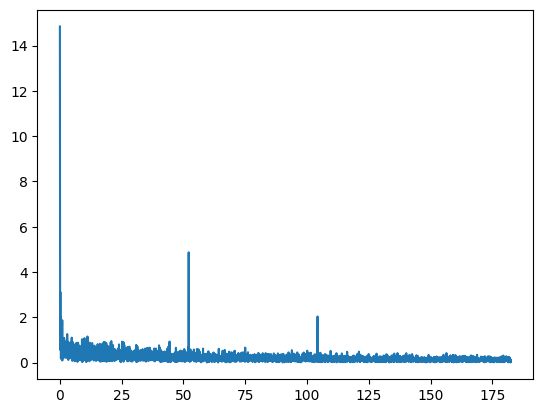

In [7]:
plt.plot(freq[mask], amp[mask])

In [8]:
print(freq[np.argsort(amp)[::-1][:10]])  # top 10 frequencies


[ 0.00000000e+00 -3.51875060e-02  3.51875060e-02  7.03750121e-02
 -7.03750121e-02 -5.21478839e+01  5.21478839e+01 -1.05562518e-01
  1.05562518e-01 -2.11125036e-01]


### Data analysis

In [9]:
seasonality = 365 / 52 # 1 week


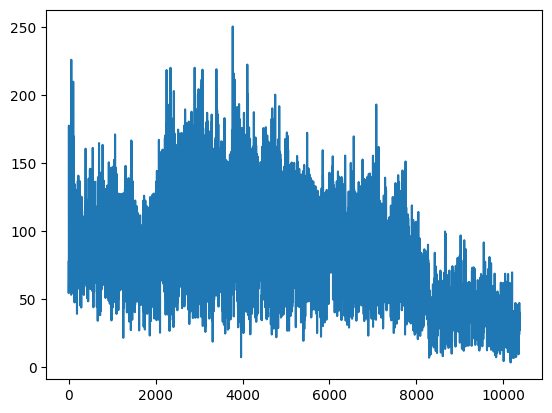

In [10]:
plt.plot(df["no2"])

### Model fitting

In [11]:
# model = csp.CmdStanModel(exe_file="../harmonic.exe")
model = csp.CmdStanModel(stan_file="..\models\harmonic.stan", force_compile=True)

17:18:28 - cmdstanpy - INFO - compiling stan file C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\models\harmonic.stan to exe file C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\models\harmonic.exe
17:18:41 - cmdstanpy - INFO - compiled model executable: C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\models\harmonic.exe


In [12]:
from utils import *
df, max_day = get_data()

In [13]:
stan_data = {
    "n": len(df),
    "t": df["day"],
    "y": df["no2"],
    "k": 2,
    "omega": np.array([2 * np.pi / (seasonality /max_day), 2*np.pi / (365.25 / max_day)])
}

In [14]:
import os
os.environ["TMPDIR"] = "C:/cmdstan_tmp"
os.environ["TEMP"] = "C:/cmdstan_tmp"
os.environ["TMP"] = "C:/cmdstan_tmp"

os.makedirs("C:/cmdstan_tmp", exist_ok=True)


In [15]:
model = csp.CmdStanModel(exe_file="../models/harmonic.exe")

In [16]:
fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    output_dir="C:/cmdstan_tmp"
)

17:18:41 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]



chain 1:   0%|          | 1/2000 [00:00<06:18,  5.28it/s, (Warmup)]


chain 1:   5%|▌         | 100/2000 [00:11<03:45,  8.42it/s, (Warmup)]


chain 1:  10%|█         | 200/2000 [00:42<06:52,  4.36it/s, (Warmup)]



chain 1:  20%|██        | 400/2000 [01:03<03:41,  7.24it/s, (Warmup)]

chain 1:  40%|████      | 800/2000 [01:16<01:00, 19.74it/s, (Warmup)]

chain 1:  55%|█████▌    | 1100/2000 [01:25<00:34, 26.00it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [01:29<00:29, 26.68it/s, (Sampling)]


chain 1:  65%|██████▌   | 1300/2000 [01:32<00:25, 27.34it/s, (Sampling)]


chain 1:  70%|███████   | 1400/2000 [01:36<00:21, 27.63it/s, (Sampling)]


chain 1:  75%|███████▌  | 1500/2000 [01:39<00:18, 27.52it/s, (Sampling)]




chain 1:  80%|████████  | 1600/2000 [01:43<00:14, 27.69it/s, (Sampling)]


chain 1:  85%|████████▌ | 1700/2000 [01:46<00:10, 28.43it/s, (Sampling)]



17:21:04 - cmdstanpy - INFO - CmdStan done processing.


In [ ]:
import arviz as az

idata = az.from_cmdstanpy(fit)
idata.to_netcdf("2_seasons.nc")

OSError: [Errno 0] Unable to synchronously create file (unable to lock file, errno = 0, error message = 'No error', Win32 GetLastError() = 33)

: 

In [ ]:
import arviz as az
 
idata = az.from_netcdf("2_seasons.nc")

                mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_cos[0]    0.420  0.451   -0.393    1.291      0.007    0.007    3648.0   
beta_cos[1]   -2.296  0.460   -3.116   -1.394      0.007    0.007    3796.0   
beta_sin[0]   -0.327  0.455   -1.129    0.546      0.007    0.008    3835.0   
beta_sin[1]    1.401  0.444    0.594    2.262      0.007    0.007    3575.0   
alpha        114.602  0.633  113.463  115.789      0.010    0.011    3895.0   
beta          -0.006  0.000   -0.006   -0.006      0.000    0.000    3920.0   
sigma         32.567  0.220   32.171   32.976      0.003    0.004    4317.0   

             ess_tail  r_hat  
beta_cos[0]    2798.0    1.0  
beta_cos[1]    2568.0    1.0  
beta_sin[0]    2535.0    1.0  
beta_sin[1]    2549.0    1.0  
alpha          2563.0    1.0  
beta           2742.0    1.0  
sigma          2805.0    1.0  


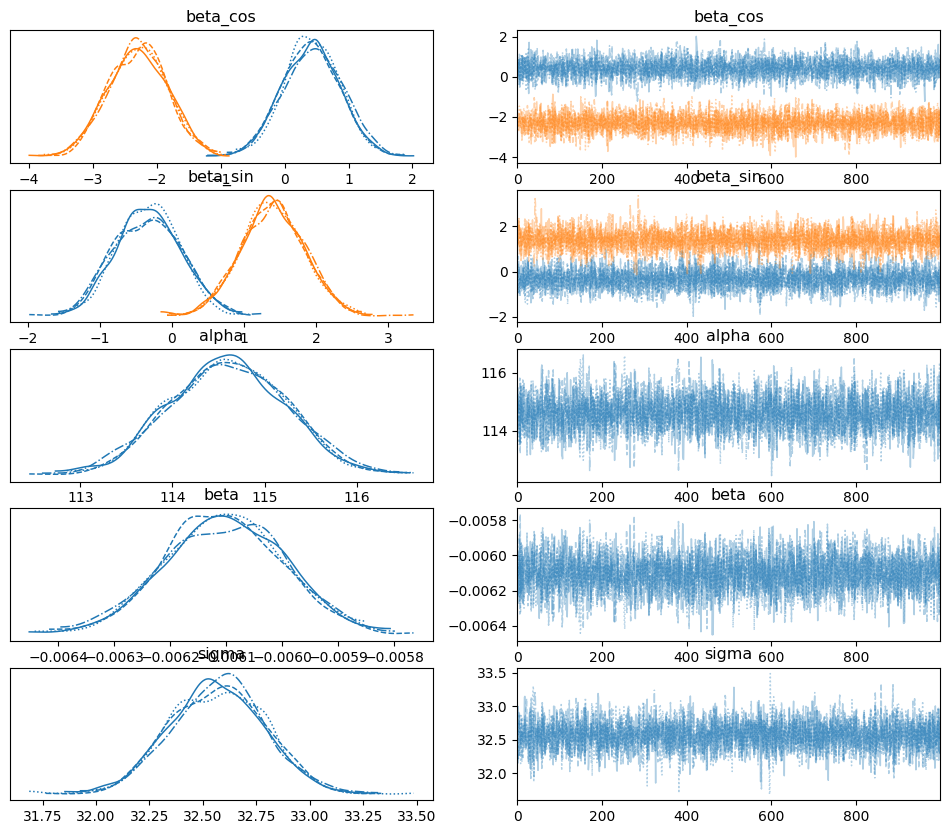

In [ ]:
import arviz as az

# Convert fit to InferenceData
# idata = az.from_cmdstanpy(fit)

# 1. Check Traceplots
# Look for "fuzzy caterpillars" - chains should overlap and not drift
az.plot_trace(idata)

# 2. Check Stats (R-hat and ESS)
summary = az.summary(idata)
print(summary)

In [ ]:
idata

Inference data with groups:
	> posterior
	> sample_stats

### LOOIC

In [ ]:
import numpy as np
import pandas as pd

# Flatten posterior draws: (chains * draws,)
def flatten(var):
    return var.values.reshape(-1, *var.shape[2:])

alpha = flatten(idata.posterior["alpha"])  # shape (n_draws,)
beta = flatten(idata.posterior["beta"])
sigma = flatten(idata.posterior["sigma"])
beta_cos = flatten(idata.posterior["beta_cos"])  # shape (n_draws, k)
beta_sin = flatten(idata.posterior["beta_sin"])

# Observed data
t_vals = np.array(stan_data["t"])
y_vals = np.array(stan_data["y"])
k = stan_data["k"]
omega = np.array(stan_data["omega"])

n_draws = alpha.shape[0]
n_obs = len(y_vals)

# Compute mu
mu = np.zeros((n_draws, n_obs))
for j in range(k):
    mu += beta_cos[:, j][:, None] * np.cos(omega[j] * t_vals)[None, :]
    mu += beta_sin[:, j][:, None] * np.sin(omega[j] * t_vals)[None, :]

# Add linear trend
mu += alpha[:, None] + beta[:, None] * t_vals

# Compute log-likelihood
log_lik = -0.5 * np.log(2 * np.pi * sigma[:, None]**2) - 0.5 * ((y_vals - mu) / sigma[:, None])**2

# Export to CSV
df_loglik = pd.DataFrame(log_lik)
df_loglik.to_csv("log_lik_simple.csv", index=False)

print("Log-likelihoods exported to log_lik_simple.csv")


Log-likelihoods exported to log_lik_simple.csv


In [ ]:
params = idata.posterior.data_vars

In [ ]:
params

Data variables:
    beta_cos  (chain, draw, beta_cos_dim_0) float64 64kB 0.3361 ... -2.025
    beta_sin  (chain, draw, beta_sin_dim_0) float64 64kB -0.2145 ... 0.9666
    alpha     (chain, draw) float64 32kB 115.6 114.3 115.0 ... 116.0 113.3 113.4
    beta      (chain, draw) float64 32kB -0.006235 -0.00604 ... -0.005917
    sigma     (chain, draw) float64 32kB 32.93 32.15 32.99 ... 32.83 32.29 32.38

In [ ]:
alphas = params["alpha"].values.reshape(-1)
betas = params["beta"].values.reshape(-1)
beta_sin = params["beta_sin"].values.reshape(-1, params["beta_sin"].shape[-1])
beta_cos = params["beta_cos"].values.reshape(-1, params["beta_cos"].shape[-1])
sigmas = params["sigma"].values.reshape(-1)

t_vals = df["day"].values
y_vals = df["no2"].values


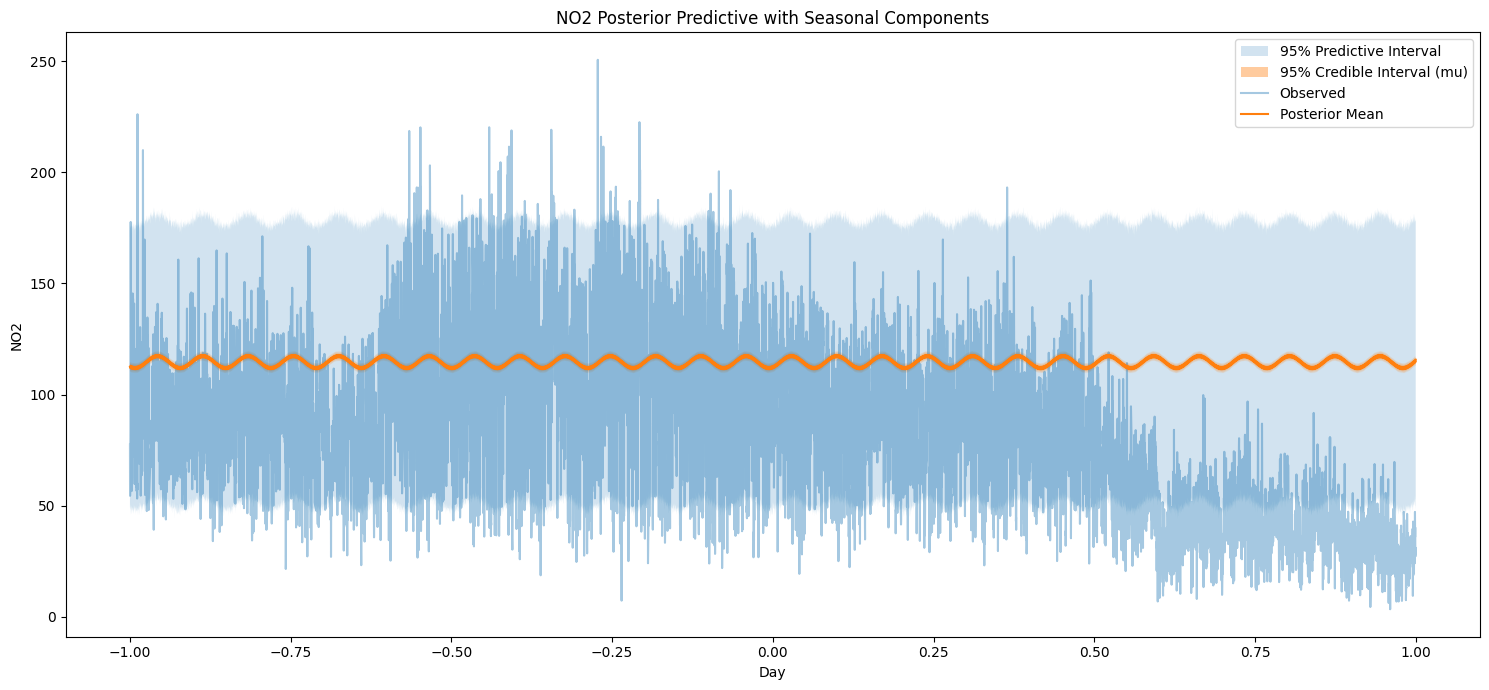

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten chains
alphas = params["alpha"].values.reshape(-1)
betas  = params["beta"].values.reshape(-1)
beta_sin = params["beta_sin"].values.reshape(-1, params["beta_sin"].shape[-1])  # (draws, k)
beta_cos = params["beta_cos"].values.reshape(-1, params["beta_cos"].shape[-1])  # (draws, k)
sigmas = params["sigma"].values.reshape(-1)

t_vals = df["day"].values
y_vals = df["no2"].values
omega = stan_data["omega"]   # shape (k,)

num_draws = alphas.shape[0]
N = len(t_vals)
k = len(omega)

# 1. Base linear trend
mu_draws = alphas[:, None] + betas[:, None] * t_vals[None, :]

# 2. Seasonal terms (vectorized, no loops over s/j)
# shapes:
# beta_*: (draws, k)
# cos/sin: (k, N)
cos_terms = np.cos(omega[:, None] * t_vals[None, :])
sin_terms = np.sin(omega[:, None] * t_vals[None, :])

mu_draws += (
    beta_cos[:, :, None] * cos_terms[None, :, :] +
    beta_sin[:, :, None] * sin_terms[None, :, :]
).sum(axis=1)

# 3. Posterior predictive
y_pred_draws = mu_draws + np.random.normal(0, sigmas[:, None], size=mu_draws.shape)

# 4. Intervals
mu_mean = mu_draws.mean(axis=0)
mu_low, mu_high = np.percentile(mu_draws, [2.5, 97.5], axis=0)

y_low, y_high = np.percentile(y_pred_draws, [2.5, 97.5], axis=0)

# 5. Plot
plt.figure(figsize=(15, 7))
plt.fill_between(t_vals, y_low, y_high, alpha=0.2, label="95% Predictive Interval")
plt.fill_between(t_vals, mu_low, mu_high, alpha=0.4, label="95% Credible Interval (mu)")
plt.plot(t_vals, y_vals, alpha=0.4, label="Observed")
plt.plot(t_vals, mu_mean, lw=1.5, label="Posterior Mean")
plt.xlabel("Day")
plt.ylabel("NO2")
plt.title("NO2 Posterior Predictive with Seasonal Components")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
np.mean(betas)

np.float64(-0.006104227557274999)

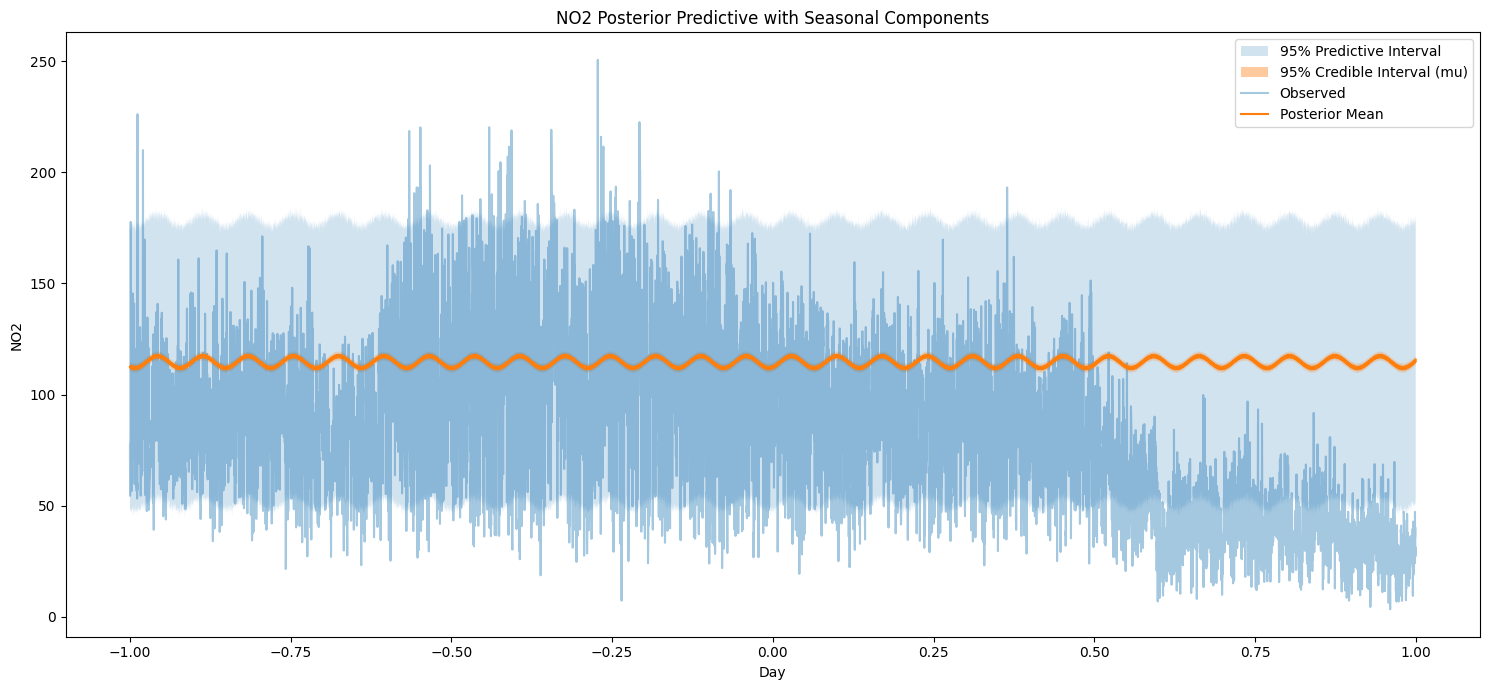

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Flatten posterior draws from idata
alphas = idata.posterior["alpha"].values.reshape(-1)          # (num_draws,)
betas = idata.posterior["beta"].values.reshape(-1)
beta_cos = idata.posterior["beta_cos"].values.reshape(-1, idata.posterior["beta_cos"].shape[-1])  # (draws, k)
beta_sin = idata.posterior["beta_sin"].values.reshape(-1, idata.posterior["beta_sin"].shape[-1])
sigmas = idata.posterior["sigma"].values.reshape(-1)

# 2. Time vector and frequencies
t_vals = df["day"].values
y_vals = df["no2"].values
omega = stan_data["omega"]  # shape (k,)
num_draws = alphas.shape[0]
N = len(t_vals)
k = len(omega)

# 3. Base linear trend
mu_draws = alphas[:, None] + betas[:, None] * t_vals[None, :]

# 4. Seasonal terms (vectorized)
cos_terms = np.cos(omega[:, None] * t_vals[None, :])  # shape (k, N)
sin_terms = np.sin(omega[:, None] * t_vals[None, :])

# Multiply each posterior draw by each harmonic and sum
mu_draws += (beta_cos[:, :, None] * cos_terms[None, :, :] +
             beta_sin[:, :, None] * sin_terms[None, :, :]).sum(axis=1)

# 5. Posterior predictive draws
y_pred_draws = mu_draws + np.random.normal(0, sigmas[:, None], size=mu_draws.shape)

# 6. Save posterior predictive draws
np.save("posterior_pred_simple.npy", y_pred_draws)

# 7. Compute summary intervals
mu_mean = mu_draws.mean(axis=0)
mu_low, mu_high = np.percentile(mu_draws, [2.5, 97.5], axis=0)
y_low, y_high = np.percentile(y_pred_draws, [2.5, 97.5], axis=0)

# 8. Plot
plt.figure(figsize=(15, 7))
plt.fill_between(t_vals, y_low, y_high, alpha=0.2, label="95% Predictive Interval")
plt.fill_between(t_vals, mu_low, mu_high, alpha=0.4, label="95% Credible Interval (mu)")
plt.plot(t_vals, y_vals, alpha=0.4, label="Observed")
plt.plot(t_vals, mu_mean, lw=1.5, label="Posterior Mean")
plt.xlabel("Day")
plt.ylabel("NO2")
plt.title("NO2 Posterior Predictive with Seasonal Components")
plt.legend()
plt.tight_layout()
plt.show()



Computed from 4000 by 10374 log-likelihood matrix.

         Estimate     SE
elpd_loo -49983.1   89.9
p_loo      3951.3 3948.1
looic     99966.3  179.8
------
MCSE of elpd_loo is NA.
MCSE and ESS estimates assume independent draws (r_eff=1).

Pareto k diagnostic values:
                         Count Pct.    Min. ESS
(-Inf, 0.7]   (good)     10373 100.0%  3876
   (0.7, 1]   (bad)          0   0.0%  <NA>
   (1, Inf)   (very bad)     1   0.0%  <NA>
See help('pareto-k-diagnostic') for details.
> 